<a href="https://colab.research.google.com/github/EOkami/ML_project/blob/main/dueling_dqn_pong_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reinforcement Learning – Dueling DQN on Pong

In [10]:
#!pip install gymnasium[atari,accept-rom-license] ale-py

import os
import math
import random
from collections import namedtuple, deque

import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from gymnasium.wrappers import AtariPreprocessing

gym.register_envs(ale_py)
from gymnasium.wrappers import FrameStackObservation

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

#  Nature DQN
BATCH_SIZE       = 32
DISCOUNT_FACTOR  = 0.99     # gamma
LEARNING_RATE    = 1e-4
EPSILON_START    = 1.0
EPSILON_END      = 0.02
EPSILON_DECAY    = 100_000
REPLAY_CAPACITY  = 10_000

# Dueling DQN
SOFT_UPDATE_TAU  = 0.005
HIDDEN_DIM       = 512

# Environment
TARGET_EPISODES  = 300
FRAME_STACK_SIZE = 4
FRAME_SIZE       = 84
CNN_FEATURE_DIM  = 3136     #64 filters × 7 × 7


Using device: cuda


In [11]:
class NormalizeFrames(gym.ObservationWrapper):

    def __init__(self, env):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0,
            shape=(FRAME_STACK_SIZE, FRAME_SIZE, FRAME_SIZE),
            dtype=np.float32)

    def observation(self, observation):
        return np.asarray(observation, dtype=np.float32) / 255.0


def build_pong_env():
    '''grayscale, resizing, frame-skip, stacking, normalization'''
    env = gym.make("PongNoFrameskip-v4", render_mode="rgb_array")
    env = AtariPreprocessing(env, screen_size=FRAME_SIZE, grayscale_obs=True, frame_skip=FRAME_STACK_SIZE)
    env = FrameStackObservation(env, stack_size=FRAME_STACK_SIZE)
    return NormalizeFrames(env)


env = build_pong_env()
num_actions = env.action_space.n
sample_obs, _ = env.reset()

print(f"Observation space : {env.observation_space.shape}")
print(f"Sample obs shape  : {sample_obs.shape}")
print(f"Number of actions : {num_actions}")


Observation space : (4, 84, 84)
Sample obs shape  : (4, 84, 84)
Number of actions : 6


In [12]:
class DuelingDQN(nn.Module):
    # Q(s,a) = V(s) + A(s,a) - mean(A(s,a))

    def __init__(self, num_actions):
        super().__init__()
        self.conv_backbone = nn.Sequential(
            nn.Conv2d(FRAME_STACK_SIZE, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten())

        self.value_head = nn.Sequential(
            nn.Linear(CNN_FEATURE_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, 1))

        self.advantage_head = nn.Sequential(
            nn.Linear(CNN_FEATURE_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, num_actions))


    def forward(self, frame_stack):
        features = self.conv_backbone(frame_stack)
        value = self.value_head(features)
        advantage = self.advantage_head(features)
        return value + (advantage - advantage.mean(dim=1, keepdim=True))


In [13]:
Transition = namedtuple("Transition", ("state", "action", "next_state", "reward", "done"))


class ReplayBuffer:

    def __init__(self, capacity):
        self._buffer = deque([], maxlen=capacity)

    def push(self, *transition_fields):
        self._buffer.append(Transition(*transition_fields))

    def sample(self, batch_size):
        return random.sample(self._buffer, batch_size)

    def __len__(self):
        return len(self._buffer)


def choose_action(state, policy_net, steps_done):
    # Epsilon-greedy action selection with exponential epsilon decay.
    epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * math.exp(
        -steps_done / EPSILON_DECAY)

    if random.random() > epsilon:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1), epsilon
    return torch.tensor([[random.randrange(env.action_space.n)]], device=DEVICE), epsilon


def compute_and_apply_loss(replay_buffer, policy_net, target_net, optimizer):

    if len(replay_buffer) < BATCH_SIZE:
        return None

    transitions = replay_buffer.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    state_batch  = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    is_non_terminal = torch.tensor([s is not None for s in batch.next_state], device=DEVICE, dtype=torch.bool)
    non_terminal_next_states = torch.cat([s for s in batch.next_state if s is not None])

    predicted_q_values = policy_net(state_batch).gather(1, action_batch)

    bootstrapped_values = torch.zeros(BATCH_SIZE, device=DEVICE)
    with torch.no_grad():
        bootstrapped_values[is_non_terminal] = target_net(non_terminal_next_states).max(1)[0]

    target_q_values = reward_batch + DISCOUNT_FACTOR * bootstrapped_values
    loss = nn.SmoothL1Loss()(predicted_q_values, target_q_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


In [14]:
CHECKPOINT_PATH = "pong_checkpoint.pth"
BEST_MODEL_PATH = "pong_best.pth"

env = build_pong_env()
policy_net = DuelingDQN(env.action_space.n).to(DEVICE)
target_net = DuelingDQN(env.action_space.n).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
replay_buffer = ReplayBuffer(REPLAY_CAPACITY)

episode_rewards = []
episode_losses = []
episode_epsilons = []
steps_done = 0
best_reward = -21.0
start_episode = 0

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    policy_net.load_state_dict(checkpoint["model_state_dict"])
    target_net.load_state_dict(policy_net.state_dict())
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    steps_done = checkpoint["steps_done"]
    episode_rewards = checkpoint["episode_rewards"]
    episode_losses = checkpoint["episode_losses"]
    episode_epsilons = checkpoint["episode_epsilons"]
    best_reward = checkpoint["best_reward"]
    start_episode = checkpoint["episode"] + 1
    print(f"Resuming from episode {start_episode}")
else:
    print("Starting fresh training session.")


Starting fresh training session.


[CNN only] seed=42
[CNN only] seed=123
[CNN only] seed=2024
[CNN + Frame Stack] seed=42
[CNN + Frame Stack] seed=123
[CNN + Frame Stack] seed=2024
[CNN + Stack + Dueling] seed=42
[CNN + Stack + Dueling] seed=123
[CNN + Stack + Dueling] seed=2024


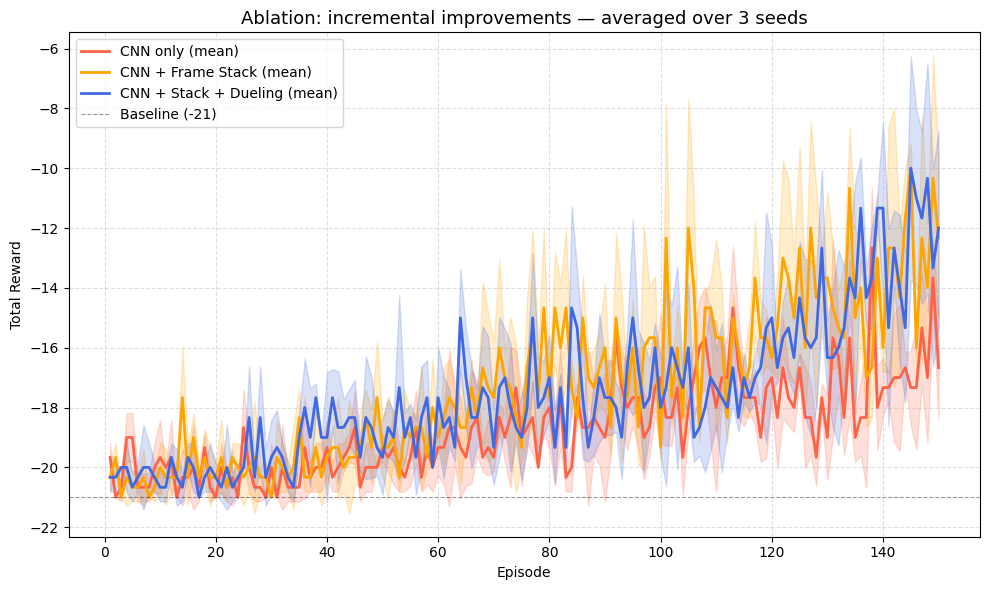

In [6]:
# CNN only vs CNN+FrameStack vs CNN+FrameStack+Dueling

ABLATION_SEEDS    = [42, 123, 2026]
ABLATION_EPISODES = 150
ABLATION_WARMUP   = 128


class CnnDqn(nn.Module):

    def __init__(self, num_actions):
        super().__init__()
        self.conv_backbone = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten())

        self.q_head = nn.Sequential(
            nn.Linear(CNN_FEATURE_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, num_actions))

    def forward(self, frame):
        return self.q_head(self.conv_backbone(frame))


class CnnStackedDqn(nn.Module):


    def __init__(self, num_actions):
        super().__init__()
        self.conv_backbone = nn.Sequential(
            nn.Conv2d(FRAME_STACK_SIZE, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten())

        self.q_head = nn.Sequential(
            nn.Linear(CNN_FEATURE_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, num_actions))

    def forward(self, frame_stack):
        return self.q_head(self.conv_backbone(frame_stack))


def build_single_frame_env():

    class _NormaliseSingleFrame(gym.ObservationWrapper):
        def __init__(self, env):
            super().__init__(env)
            self.observation_space = gym.spaces.Box(
                low=0.0, high=1.0, shape=(1, FRAME_SIZE, FRAME_SIZE), dtype=np.float32
            )

        def observation(self, obs):
            return np.asarray(obs, dtype=np.float32)[np.newaxis] / 255.0

    env = gym.make("PongNoFrameskip-v4", render_mode="rgb_array")
    env = AtariPreprocessing(env, screen_size=FRAME_SIZE, grayscale_obs=True, frame_skip=FRAME_STACK_SIZE)
    return _NormaliseSingleFrame(env)


def run_ablation_training(network_class, seed, num_episodes, use_frame_stack):

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    train_env = build_pong_env() if use_frame_stack else build_single_frame_env()
    policy = network_class(train_env.action_space.n).to(DEVICE)
    target = network_class(train_env.action_space.n).to(DEVICE)
    target.load_state_dict(policy.state_dict())
    opt = optim.Adam(policy.parameters(), lr=LEARNING_RATE)
    buf = ReplayBuffer(REPLAY_CAPACITY)
    total_steps = 0
    rewards = []

    for _ in range(num_episodes):
        obs, _ = train_env.reset()
        state = torch.tensor(obs, device=DEVICE).unsqueeze(0)
        episode_reward = 0.0
        is_done = False

        while not is_done:
            epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * math.exp(-total_steps / EPSILON_DECAY)
            if random.random() > epsilon:
                with torch.no_grad():
                    action = policy(state).max(1)[1].view(1, 1)
            else:
                action = torch.tensor([[random.randrange(train_env.action_space.n)]], device=DEVICE)

            next_obs, reward, terminated, truncated, _ = train_env.step(action.item())
            is_done = terminated or truncated
            total_steps += 1
            episode_reward += reward

            next_state = (
                torch.tensor(next_obs, device=DEVICE).unsqueeze(0)
                if not is_done else None
            )
            buf.push(
                state, action, next_state,
                torch.tensor([reward], device=DEVICE),
                torch.tensor([is_done], device=DEVICE),
            )
            state = next_state

            if len(buf) >= ABLATION_WARMUP:
                compute_and_apply_loss(buf, policy, target, opt)

            for t_param, p_param in zip(target.parameters(), policy.parameters()):
                t_param.data.copy_(
                    SOFT_UPDATE_TAU * p_param.data + (1.0 - SOFT_UPDATE_TAU) * t_param.data
                )

        rewards.append(episode_reward)

    train_env.close()
    return rewards


def plot_ablation_comparison(results_per_variant):

    episode_axis = np.arange(1, ABLATION_EPISODES + 1)
    colors = {"CNN only": "tomato", "CNN + Frame Stack": "orange", "CNN + Stack + Dueling": "royalblue"}

    plt.figure(figsize=(10, 6))

    for label, seed_rewards in results_per_variant.items():
        reward_array = np.array(seed_rewards)
        mean = reward_array.mean(axis=0)
        std  = reward_array.std(axis=0)
        color = colors[label]
        plt.plot(episode_axis, mean, color=color, linewidth=2, label=f"{label} (mean)")
        plt.fill_between(episode_axis, mean - std, mean + std, color=color, alpha=0.2)

    plt.axhline(y=-21, color="black", linestyle="--", linewidth=0.8, alpha=0.4, label="Baseline (-21)")
    plt.title(
        f"Ablation: incremental improvements — averaged over {len(ABLATION_SEEDS)} seeds",
        fontsize=13,
    )
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


ABLATION_VARIANTS = {
    "CNN only": (CnnDqn, False),
    "CNN + Frame Stack": (CnnStackedDqn, True),
    "CNN + Stack + Dueling": (DuelingDQN, True),
}

ablation_results = {label: [] for label in ABLATION_VARIANTS}

for label, (network_class, use_stack) in ABLATION_VARIANTS.items():
    for seed in ABLATION_SEEDS:
        print(f"[{label}] seed={seed}")
        ablation_results[label].append(
            run_ablation_training(network_class, seed, ABLATION_EPISODES, use_stack)
        )

plot_ablation_comparison(ablation_results)

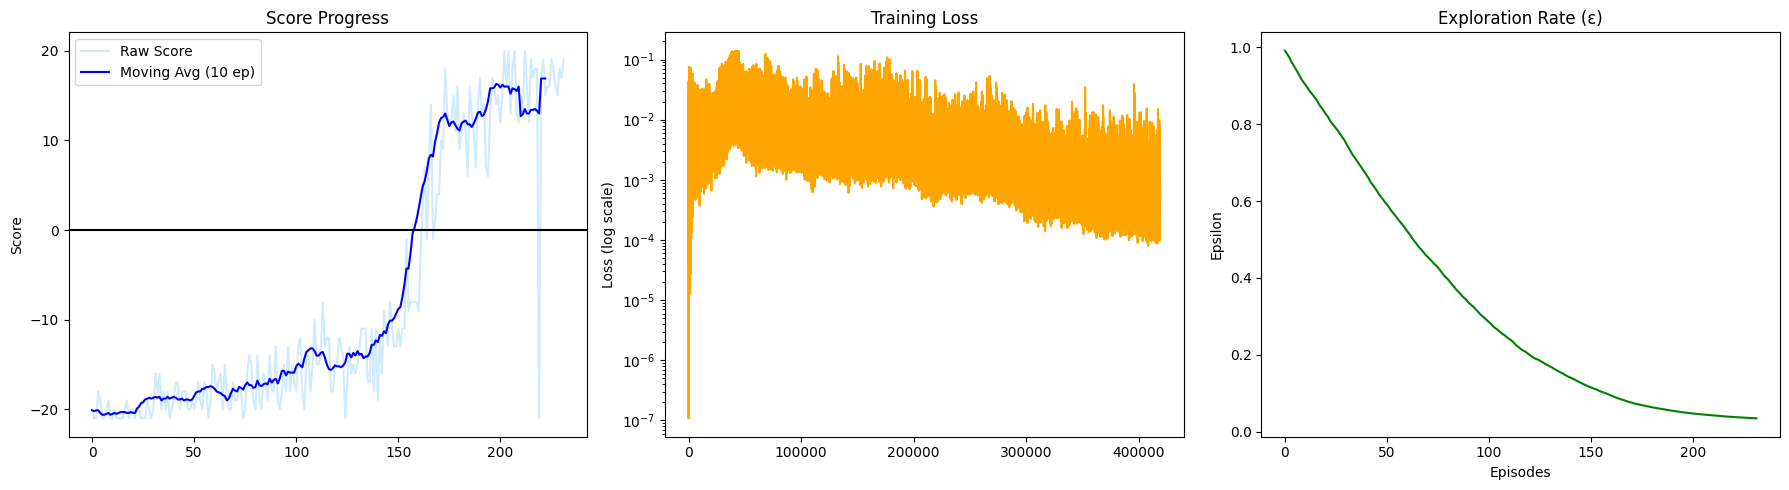

In [ ]:
from IPython.display import clear_output


def plot_training_progress(rewards, losses, epsilons):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    #Score
    axes[0].set_title("Score Progress")
    axes[0].plot(rewards, color="lightskyblue", alpha=0.4, label="Raw Score")
    if len(rewards) > 10:
        moving_avg = np.convolve(rewards, np.ones(10) / 10, mode="valid")
        axes[0].plot(moving_avg, color="blue", label="Moving Avg (10 ep)")
    axes[0].axhline(y=0, color="black", linestyle="-")
    axes[0].set_ylabel("Score")
    axes[0].legend()

    #Training loss (log scale)
    axes[1].set_title("Training Loss")
    axes[1].plot(losses, color="orange")
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Loss (log scale)")

    #Epsilon decay
    axes[2].set_title("Exploration Rate (ε)")
    axes[2].plot(epsilons, color="green")
    axes[2].set_ylabel("Epsilon")
    axes[2].set_xlabel("Episodes")

    plt.tight_layout()
    plt.show()


MAX_STEPS_PER_EPISODE = 10_000

for episode_idx in range(start_episode, TARGET_EPISODES):
    obs, _ = env.reset()
    current_state = torch.tensor(obs, device=DEVICE).unsqueeze(0)
    episode_total_reward = 0.0

    for _ in range(MAX_STEPS_PER_EPISODE):
        action, current_epsilon = choose_action(current_state, policy_net, steps_done)
        steps_done += 1

        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        episode_total_reward += reward
        is_done = terminated or truncated

        next_state = (
            torch.tensor(next_obs, device=DEVICE).unsqueeze(0) if not is_done else None
        )
        replay_buffer.push(
            current_state,
            action,
            next_state,
            torch.tensor([reward], device=DEVICE),
            torch.tensor([is_done], device=DEVICE),
        )
        current_state = next_state

        step_loss = compute_and_apply_loss(replay_buffer, policy_net, target_net, optimizer)
        if step_loss is not None:
            episode_losses.append(step_loss)

        for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
            target_param.data.copy_(
                SOFT_UPDATE_TAU * policy_param.data + (1.0 - SOFT_UPDATE_TAU) * target_param.data
            )

        if is_done:
            break

    episode_rewards.append(episode_total_reward)
    episode_epsilons.append(current_epsilon)

    torch.save({
            "episode": episode_idx,
            "steps_done": steps_done,
            "model_state_dict": policy_net.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "episode_rewards": episode_rewards,
            "episode_losses": episode_losses,
            "episode_epsilons": episode_epsilons,
            "best_reward": max(best_reward, episode_total_reward),
        },CHECKPOINT_PATH)

    if episode_total_reward > best_reward:
        best_reward = episode_total_reward
        torch.save(policy_net.state_dict(), BEST_MODEL_PATH)

    plot_training_progress(episode_rewards, episode_losses, episode_epsilons)

print(f"Training complete — {len(episode_rewards)} episodes.")


In [2]:
def run_greedy_evaluation(num_episodes = 5):
    if os.path.exists(BEST_MODEL_PATH):
        policy_net.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    policy_net.eval()

    greedy_rewards = []
    print(f"Evaluating over {num_episodes} episodes (greedy policy)...")

    for episode_idx in range(num_episodes):
        obs, _ = env.reset()
        current_state = torch.tensor(obs, device=DEVICE).unsqueeze(0)
        episode_total_reward = 0.0
        is_done = False

        while not is_done:
            with torch.no_grad():
                action = policy_net(current_state).max(1)[1].view(1, 1)
            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            episode_total_reward += reward
            current_state = torch.tensor(next_obs, device=DEVICE).unsqueeze(0)
            is_done = terminated or truncated

        greedy_rewards.append(episode_total_reward)
        print(f"  Episode {episode_idx + 1}: {episode_total_reward}")

    print(f"Average score: {np.mean(greedy_rewards):.2f}")


run_greedy_evaluation()


NameError: name 'os' is not defined

In [1]:
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay > /dev/null 2>&1

from gymnasium.wrappers import RecordVideo
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()


def record_agent_episode(output_folder: str = "./videos") -> None:
    """Record one full episode of the best saved model and save it as a video."""
    recording_env = build_pong_env()
    recording_env = RecordVideo(
        recording_env,
        video_folder=output_folder,
        episode_trigger=lambda _: True,
        name_prefix="pong_agent",
    )

    policy_net.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    policy_net.eval()

    obs, _ = recording_env.reset()
    is_done = False

    while not is_done:
        state_tensor = torch.tensor(obs, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            action = policy_net(state_tensor).max(1)[1].view(1, 1)
        obs, _, terminated, truncated, _ = recording_env.step(action.item())
        is_done = terminated or truncated

    recording_env.close()
    print(f"Video saved to '{output_folder}'.")


record_agent_episode()


ModuleNotFoundError: No module named 'pyvirtualdisplay'